# **PRAKTIKUM PERTEMUAN 11 DATA SCIENCE**

Nama : Ninis Indah Trisia

NIM : 250401020094

Kelas : IF405

### Generate & Eksplorasi Dataset

Shape: (300, 4)


,pendapatan_tahunan,skor_belanja,usia,gender
0,32.980285,18.893886,64,P
1,33.886131,32.184239,21,P
2,28.595080,18.126904,29,L
3,39.475277,26.139478,62,L
4,27.183154,24.340480,19,L


       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


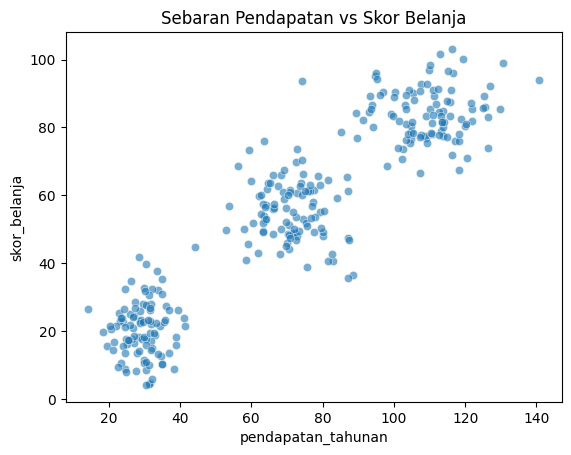

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros

data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])

df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print("Shape:", df.shape)

display(df.head())

print(df.describe().round(2))

sns.scatterplot(
    data=df,
    x='pendapatan_tahunan',
    y='skor_belanja',
    alpha=0.6
)

plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

### Preprocessing Data

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling :", X_scaled.mean(axis=0).round(3))
print("Std setelah scaling :", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling : [-0.  0.]
Std setelah scaling : [1. 1.]


### Metode Elbow

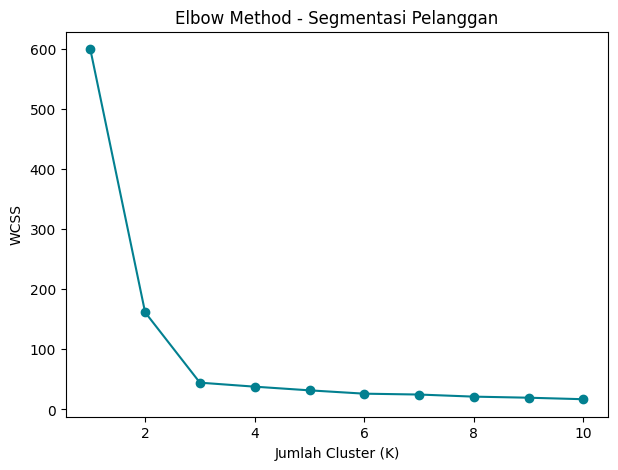

In [3]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init='k-means++'
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker='o', color='#028090')

plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method - Segmentasi Pelanggan")

plt.show()

Metode Elbow digunakan untuk menentukan jumlah cluster yang paling sesuai. Caranya dengan membandingkan nilai WCSS untuk beberapa jumlah cluster. Dari grafik yang dihasilkan, titik yang mulai melandai menunjukkan jumlah cluster yang paling optimal, yaitu 3 cluster.

### Melatih Model K-Means

In [4]:
from sklearn.metrics import silhouette_score

model = KMeans(
    n_clusters=3,
    random_state=42,
    init='k-means++'
)

model.fit(X_scaled)

df['cluster'] = model.labels_

print(f"WCSS akhir : {model.inertia_:.3f}")

print(f"Silhouette Score : {silhouette_score(X_scaled, model.labels_):.3f}")

display(
    df.groupby('cluster')[['pendapatan_tahunan','skor_belanja']].mean().round(2)
)

WCSS akhir : 44.556
Silhouette Score : 0.695


,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


Setelah mengetahui jumlah cluster yang optimal, model K-Means dilatih menggunakan 3 cluster. Kemudian ditampilkan nilai WCSS, Silhouette Score, dan rata-rata setiap cluster untuk mengetahui kualitas hasil pengelompokan.

### Visualisasi Hasil Clustering

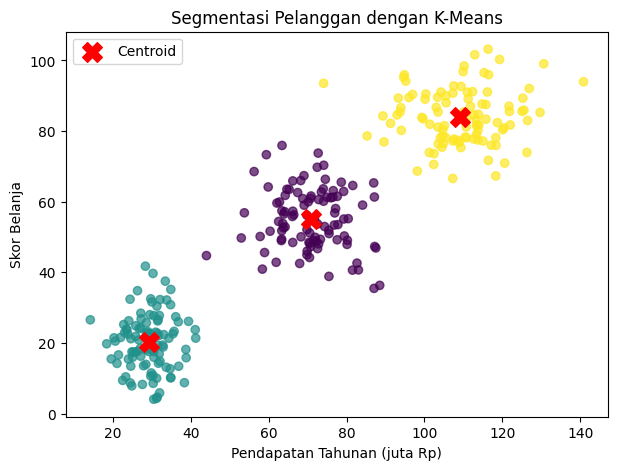

In [5]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7,5))

plt.scatter(
    df['pendapatan_tahunan'],
    df['skor_belanja'],
    c=df['cluster'],
    cmap='viridis',
    alpha=0.7
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    marker='X',
    s=200,
    label='Centroid'
)

plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")

plt.legend()

plt.show()

Interpretasi Cluster:

*   Cluster 0: Pendapatan rendah dan skor belanja rendah (Segmen Hemat).
*   Cluster 1: Pendapatan sedang dan skor belanja sedang (Segmen Menengah).
*   Cluster 2: Pendapatan tinggi dan skor belanja tinggi (Segmen Premium/Boros).

### Hierarchical Clustering

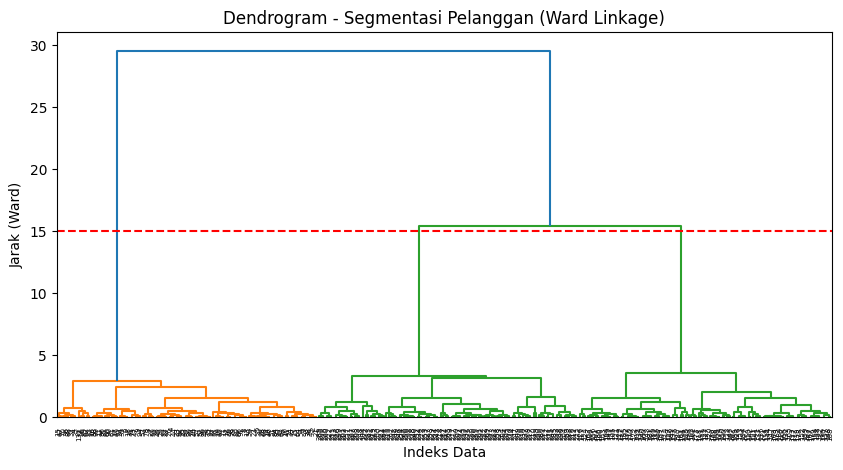

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(10,5))

dendrogram(Z)

plt.title("Dendrogram - Segmentasi Pelanggan (Ward Linkage)")

plt.xlabel("Indeks Data")
plt.ylabel("Jarak (Ward)")

plt.axhline(y=15, color='red', linestyle='--')

plt.show()

Digunakan metode Hierarchical Clustering sebagai pembanding. Hasilnya ditampilkan dalam bentuk dendrogram. Dari dendrogram terlihat bahwa data juga dapat dibagi menjadi sekitar 3 kelompok, sehingga hasilnya sesuai dengan metode K-Means.

# Kesimpulan
Pada praktikum pertemuan 11 ini, data pelanggan berhasil dikelompokkan menggunakan metode K-Means Clustering. Dari hasil Metode Elbow, diperoleh jumlah cluster yang paling sesuai yaitu 3 cluster. Hasil tersebut juga didukung oleh visualisasi yang menunjukkan bahwa data terbagi menjadi tiga kelompok yang jelas, yaitu pelanggan dengan pendapatan dan skor belanja rendah, menengah, dan tinggi. Selain itu, hasil Hierarchical Clustering juga menunjukkan pembagian yang hampir sama. Dengan demikian, metode clustering dapat membantu mengelompokkan pelanggan berdasarkan karakteristiknya sehingga lebih mudah untuk dianalisis.